# Examen aplicado de Machine Learning I

**Estudiante:** Oscar Aguilera  
**Dataset:** Bike Sharing Dataset - archivo diario `day.csv`  
**Fuente:** UCI Machine Learning Repository  
**URL pública:** https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset  
**Dimensiones del archivo analizado:** 731 filas x 16 columnas  
**Variables predictoras utilizadas:** 11 (4 numéricas continuas, 3 nominales y 4 ordinales/binarias)  
**Variable objetivo:** `cnt`, cantidad total diaria de arriendos  
**Tipo de tarea:** regresión

## 1. Planteamiento y criterio de negocio

El propósito es estimar la demanda diaria de bicicletas para apoyar decisiones de disponibilidad, redistribución y dotación. Se espera que la temperatura, la sensación térmica, el año, la estación y el estado meteorológico sean predictores relevantes. El archivo diario cumple los mínimos del examen y representa un problema real: contiene observaciones de Capital Bikeshare de 2011 y 2012 junto con información meteorológica y estacional (Fanaee-T, 2013).

Se excluyen `instant`, porque es un identificador; `dteday`, porque su información ya está representada mediante año, mes y día de semana; y `casual` y `registered`, porque su suma es exactamente `cnt`. Usar esas dos últimas variables produciría *target leakage* y una evaluación artificialmente optimista.

In [1]:
# Librerías, estilo y semilla común: todas las decisiones aleatorias son reproducibles.
import json, os, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# `display` is replaced by the notebook kernel; the fallback keeps the
# script executable in minimal Python environments as well.
def display(obj): print(obj)
def Markdown(text): return text

from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error,
                             mean_squared_error, r2_score, silhouette_score)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
set_config(display='diagram')

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)
def save_figure(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=150, bbox_inches='tight')
    plt.show()

## 2. Carga e inspección inicial

In [2]:
# Se carga con pandas desde una copia local del archivo original de UCI.
df = pd.read_csv('data/day.csv')
print('df.shape =', df.shape)
display(df.head())

df.shape = (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
print('Tipos de datos:')
display(df.dtypes.to_frame('dtype'))
print('\nInformación del DataFrame:')
df.info()
print('\nResumen descriptivo:')
display(df.describe(include='all').T)

Tipos de datos:

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Resumen descriptivo:


,dtype
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
instant,731.0,NaN,NaN,NaN,366.0,211.165812,1.0,183.5,366.0,548.5,731.0
dteday,731,731,2011-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,731.0,NaN,NaN,NaN,2.49658,1.110807,1.0,2.0,3.0,3.0,4.0
yr,731.0,NaN,NaN,NaN,0.500684,0.500342,0.0,0.0,1.0,1.0,1.0
mnth,731.0,NaN,NaN,NaN,6.519836,3.451913,1.0,4.0,7.0,10.0,12.0
holiday,731.0,NaN,NaN,NaN,0.028728,0.167155,0.0,0.0,0.0,0.0,1.0
weekday,731.0,NaN,NaN,NaN,2.997264,2.004787,0.0,1.0,3.0,5.0,6.0
workingday,731.0,NaN,NaN,NaN,0.683995,0.465233,0.0,0.0,1.0,1.0,1.0
weathersit,731.0,NaN,NaN,NaN,1.395349,0.544894,1.0,1.0,1.0,2.0,3.0
temp,731.0,NaN,NaN,NaN,0.495385,0.183051,0.05913,0.337083,0.498333,0.655417,0.861667


### Definición de variables

- Numéricas continuas: `temp`, `atemp`, `hum`, `windspeed`.
- Nominales: `season`, `mnth`, `weekday`.
- Ordinales/binarias: `yr`, `holiday`, `workingday`, `weathersit`.
- Objetivo: `cnt`.

Aunque varias categorías llegan codificadas como enteros, no deben interpretarse automáticamente como magnitudes continuas. Por ello se separan explícitamente en el `ColumnTransformer`.

In [4]:
target = 'cnt'
numeric_features = ['temp', 'atemp', 'hum', 'windspeed']
nominal_features = ['season', 'mnth', 'weekday']
ordinal_features = ['yr', 'holiday', 'workingday', 'weathersit']
feature_cols = numeric_features + nominal_features + ordinal_features
excluded = ['instant', 'dteday', 'casual', 'registered']

X = df[feature_cols].copy()
y = df[target].copy()
print('Predictores:', X.shape, '| Objetivo:', y.shape)
print('Comprobación de fuga casual + registered == cnt:',
      bool((df['casual'] + df['registered'] == df['cnt']).all()))

Predictores: (731, 11) | Objetivo: (731,)
Comprobación de fuga casual + registered == cnt: True


## 3. Datos faltantes y valores atípicos

,% nulos
instant,0.0
dteday,0.0
season,0.0
yr,0.0
mnth,0.0
holiday,0.0
weekday,0.0
workingday,0.0
weathersit,0.0
temp,0.0


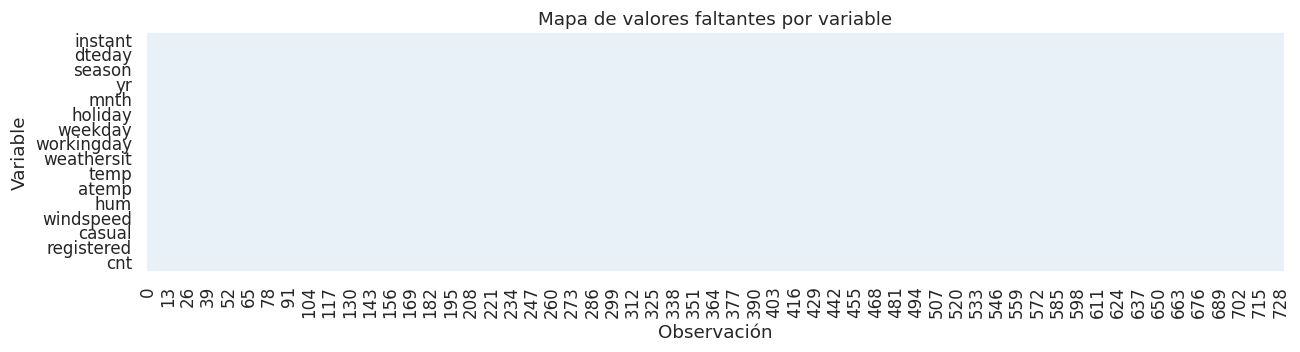

In [5]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).to_frame('% nulos')
display(missing_pct)

plt.figure(figsize=(12, 3.4))
sns.heatmap(df.isna().T, cbar=False, yticklabels=True, cmap=['#e8f1f8'])
plt.title('Mapa de valores faltantes por variable')
plt.xlabel('Observación')
plt.ylabel('Variable')
save_figure('01_missing_values_heatmap.png')

**Decisión sobre nulos.** El archivo no contiene valores faltantes, por lo que no se elimina ni modifica ninguna fila o columna. Aun así, el pipeline incorpora imputación por mediana para variables numéricas y por moda para variables categóricas como protección reproducible frente a datos futuros. Estos imputadores se ajustan únicamente con datos de entrenamiento.

,variable,Q1,Q3,límite inferior,límite superior,n outliers,% outliers
0,temp,0.3371,0.6554,-0.1404,1.1329,0,0.0000
1,atemp,0.3378,0.6086,-0.0683,1.0147,0,0.0000
2,hum,0.5200,0.7302,0.2047,1.0455,2,0.2736
3,windspeed,0.1349,0.2332,-0.0124,0.3806,13,1.7784


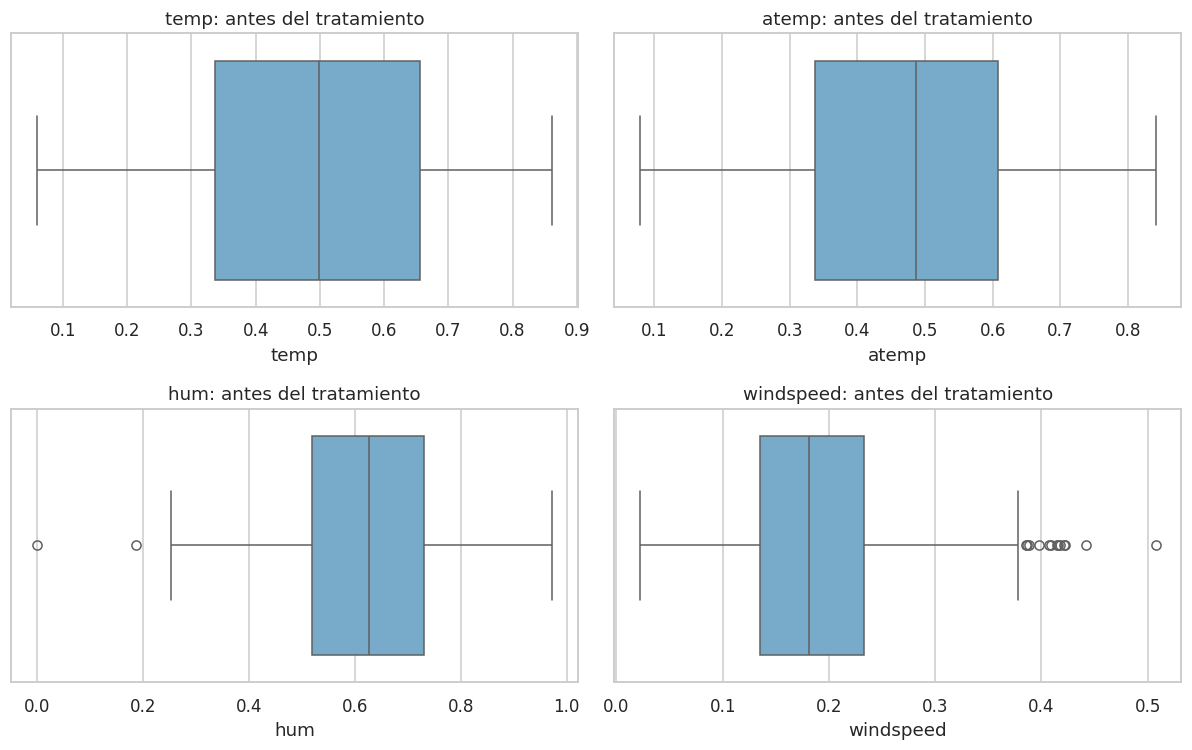

In [6]:
# Diagnóstico IQR descriptivo: todavía no se modifica ningún dato.
iqr_rows = []
for col in numeric_features:
    q1, q3 = X[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = int(((X[col] < low) | (X[col] > high)).sum())
    iqr_rows.append([col, q1, q3, low, high, count, 100*count/len(X)])
outlier_table = pd.DataFrame(iqr_rows, columns=['variable','Q1','Q3','límite inferior','límite superior','n outliers','% outliers'])
display(outlier_table.round(4))

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for col, ax in zip(numeric_features, axes.ravel()):
    sns.boxplot(x=X[col], ax=ax, color='#6baed6')
    ax.set_title(f'{col}: antes del tratamiento')
    ax.set_xlabel(col)
save_figure('02_boxplots_outliers_antes.png')

**Decisión sobre outliers.** No se eliminan días completos: humedad y viento extremos son condiciones plausibles y operacionalmente relevantes. Para reducir su influencia sobre Ridge y PCA, se aplica *winsorization* IQR dentro del pipeline: cada variable numérica se limita a Q1 - 1,5·IQR y Q3 + 1,5·IQR. Los límites se aprenden solo en entrenamiento; así se conserva el tamaño muestral y se evita fuga desde test.

## 4. Análisis exploratorio de datos (EDA)

Skewness de cnt = -0.0474
Transformación logarítmica: no necesaria


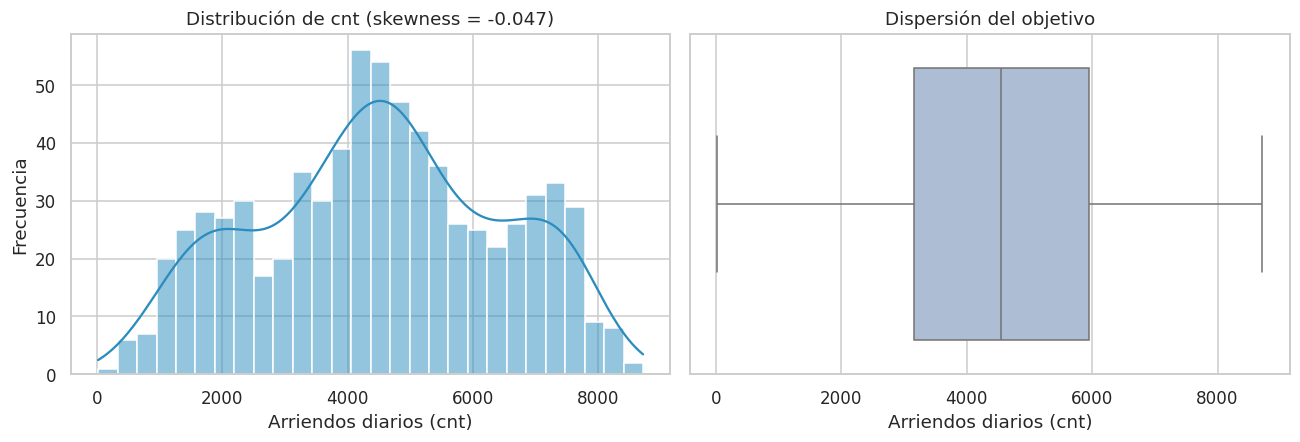

In [7]:
target_skew = y.skew()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.histplot(y, kde=True, bins=28, ax=axes[0], color='#2b8cbe')
axes[0].set_title(f'Distribución de cnt (skewness = {target_skew:.3f})')
axes[0].set_xlabel('Arriendos diarios (cnt)')
axes[0].set_ylabel('Frecuencia')
sns.boxplot(x=y, ax=axes[1], color='#a6bddb')
axes[1].set_title('Dispersión del objetivo')
axes[1].set_xlabel('Arriendos diarios (cnt)')
save_figure('03_distribucion_objetivo.png')
print(f'Skewness de cnt = {target_skew:.4f}')
print('Transformación logarítmica:', 'evaluar' if abs(target_skew) > 1 else 'no necesaria')

La asimetría del objetivo es muy inferior al umbral de 1,0; por tanto, no se transforma `cnt`. Mantener la escala original facilita explicar el error directamente como número de arriendos diarios.

,correlación con cnt
atemp,0.631066
temp,0.627494
yr,0.566710
season,0.406100
weathersit,-0.297391


,predictor 1,predictor 2,r
0,temp,atemp,0.991702


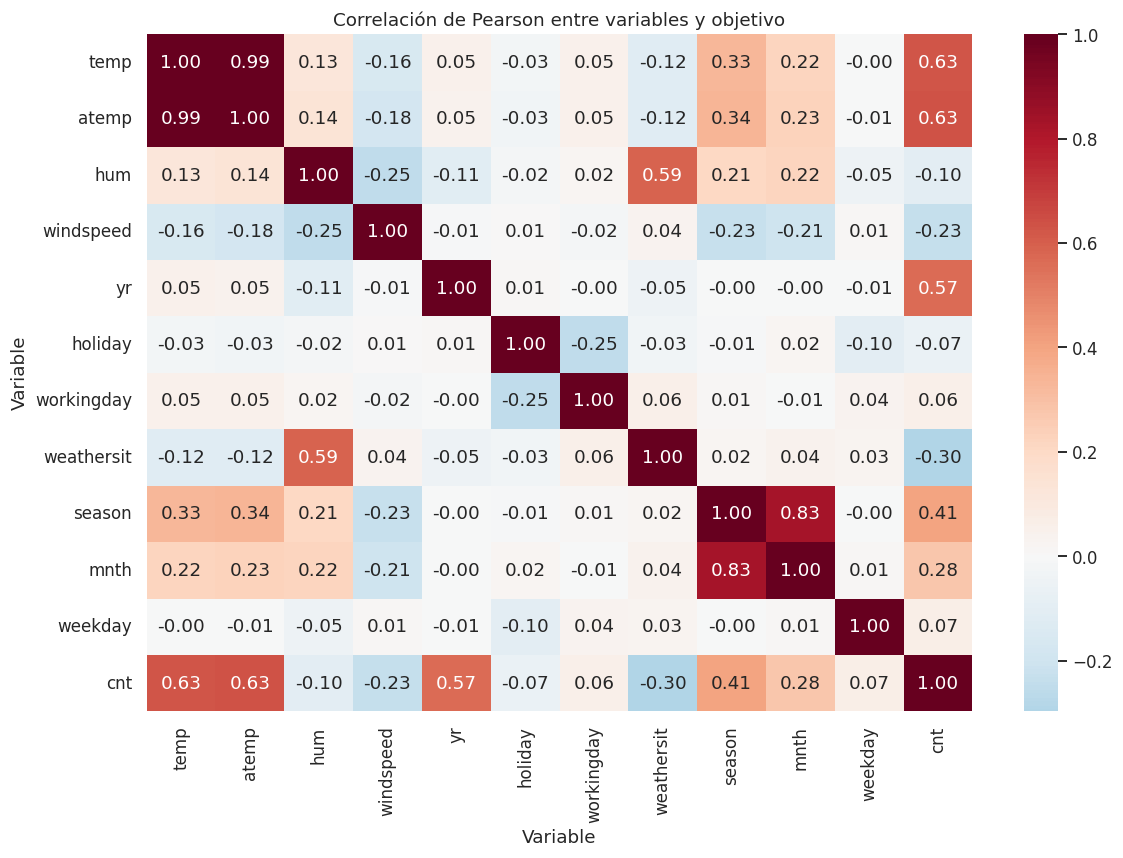

In [8]:
corr_cols = numeric_features + ordinal_features + nominal_features + [target]
corr = df[corr_cols].corr(method='pearson')
plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=True, fmt='.2f', square=False)
plt.title('Correlación de Pearson entre variables y objetivo')
plt.xlabel('Variable')
plt.ylabel('Variable')
save_figure('04_heatmap_correlacion.png')

target_corr = corr[target].drop(target).sort_values(key=np.abs, ascending=False)
top5_corr = target_corr.head(5).to_frame('correlación con cnt')
display(top5_corr)
high_pairs = []
predictor_corr = corr.drop(index=target, columns=target)
for i, a in enumerate(predictor_corr.columns):
    for b in predictor_corr.columns[i+1:]:
        if abs(predictor_corr.loc[a, b]) > 0.85:
            high_pairs.append([a, b, predictor_corr.loc[a, b]])
multicollinearity = pd.DataFrame(high_pairs, columns=['predictor 1','predictor 2','r'])
display(multicollinearity if not multicollinearity.empty else 'No hay pares con |r| > 0.85')

`temp` y `atemp` presentan multicolinealidad alta. Se mantienen porque capturan temperatura medida y percibida, Ridge controla coeficientes inestables mediante penalización L2 y Random Forest no depende de independencia lineal. La comparación posterior entre correlaciones e importancia permitirá comprobar si ambas aportan señal o si el árbol concentra el valor predictivo en una de ellas.

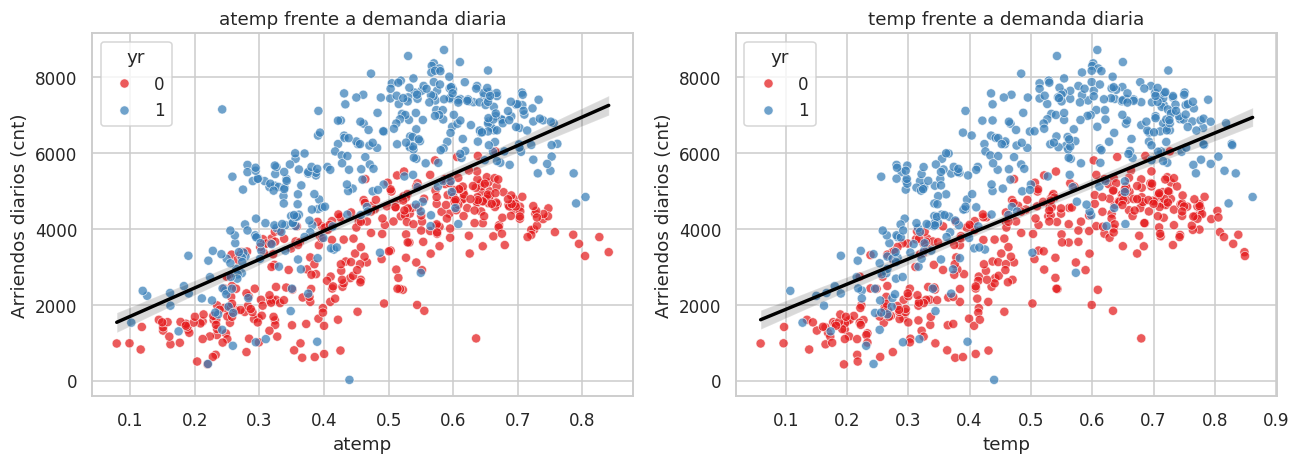

In [9]:
two_best = target_corr.abs().head(2).index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for col, ax in zip(two_best, axes):
    sns.scatterplot(data=df, x=col, y=target, hue='yr', palette='Set1', alpha=.72, ax=ax)
    sns.regplot(data=df, x=col, y=target, scatter=False, color='black', ax=ax)
    ax.set_title(f'{col} frente a demanda diaria')
    ax.set_xlabel(col)
    ax.set_ylabel('Arriendos diarios (cnt)')
save_figure('05_scatter_top_correlations.png')

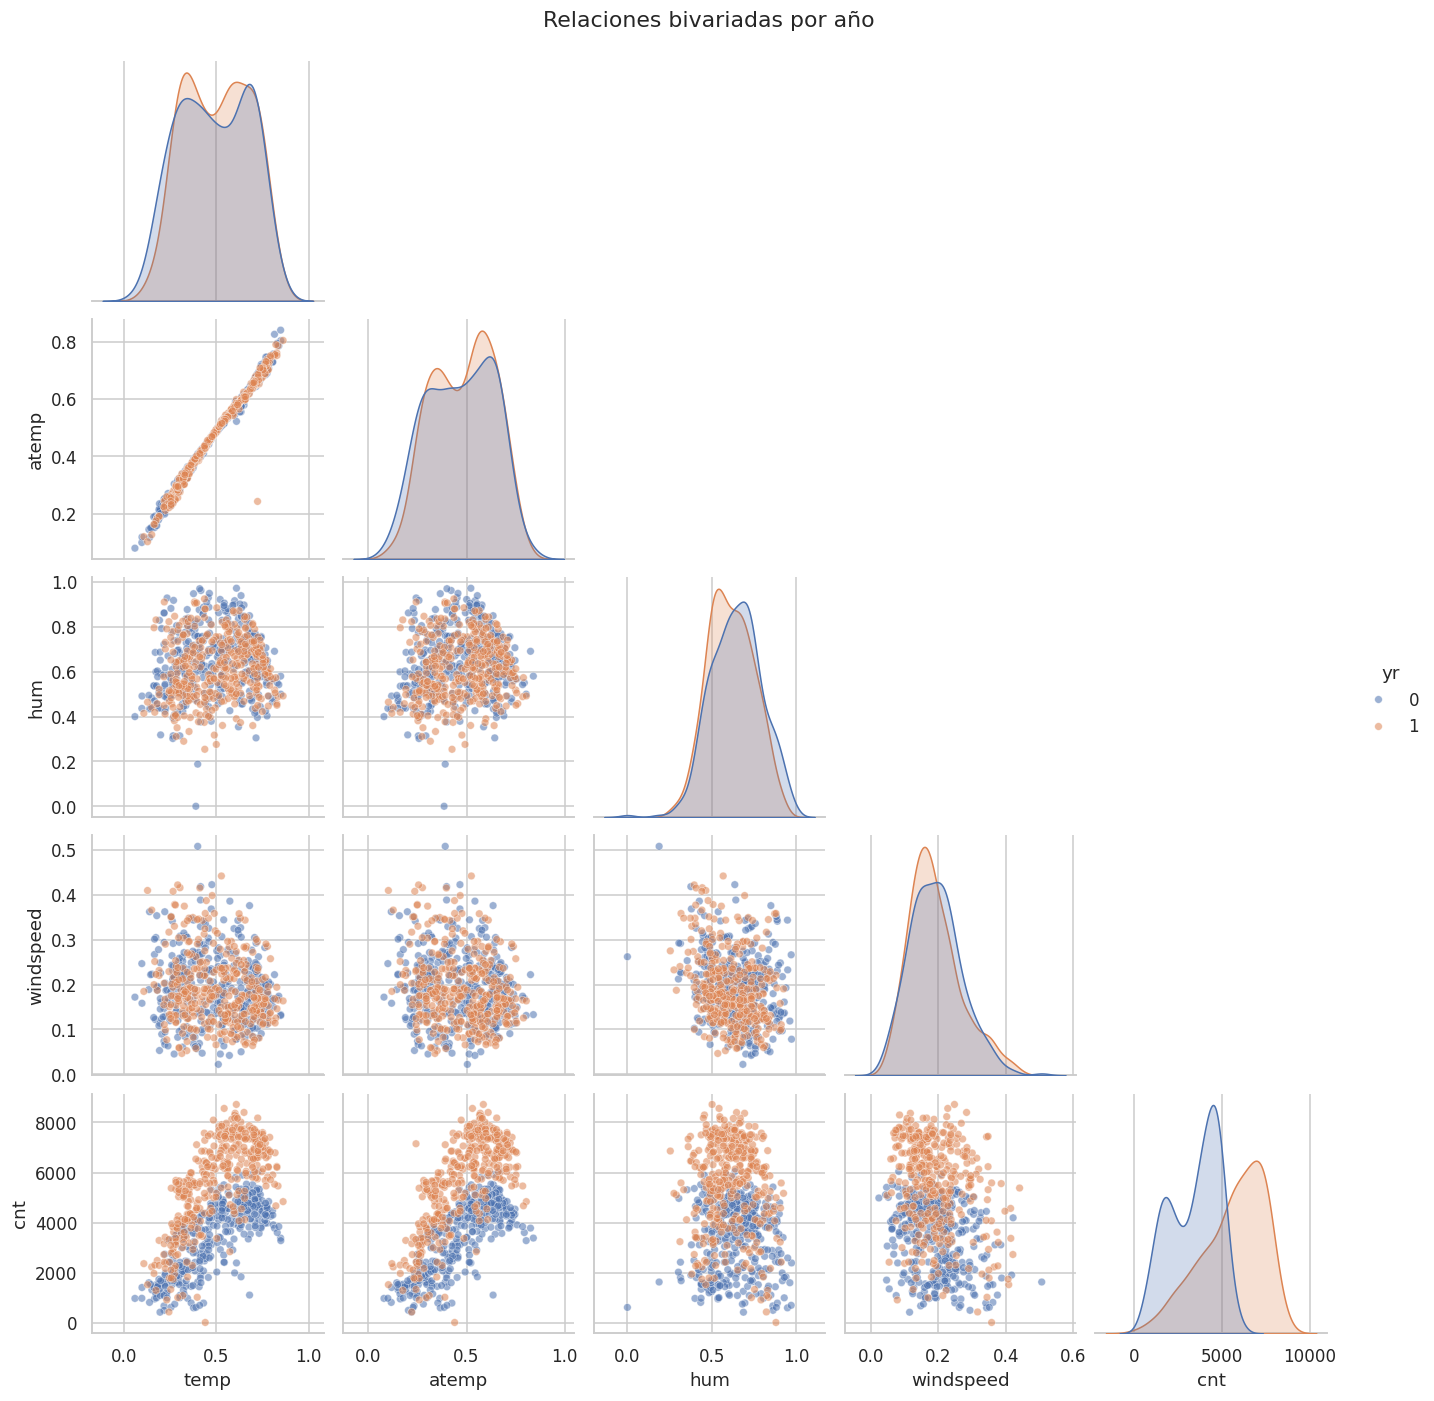

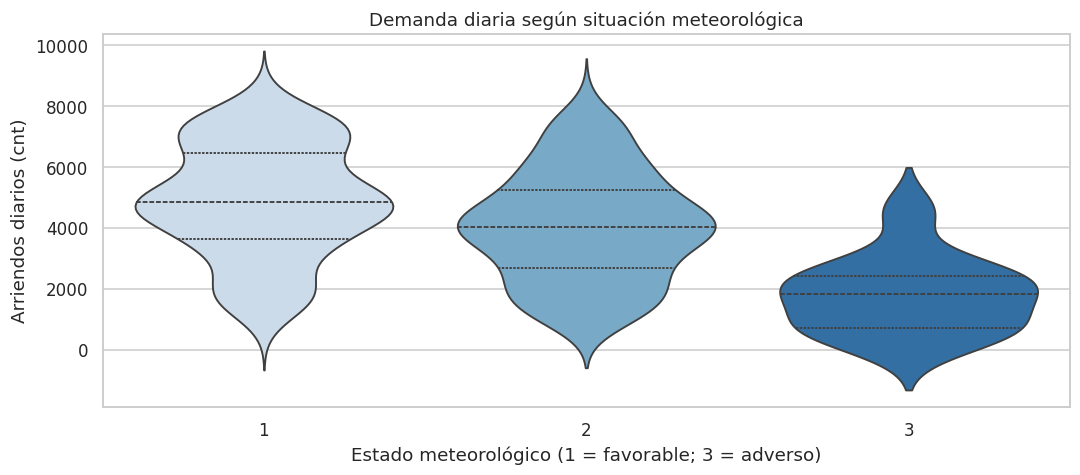

In [10]:
sample_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt', 'yr']
g = sns.pairplot(df[sample_cols], hue='yr', corner=True, plot_kws={'alpha':.55, 's':25})
g.fig.suptitle('Relaciones bivariadas por año', y=1.02)
g.fig.savefig(FIG_DIR / '06_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 4.5))
sns.violinplot(data=df, x='weathersit', y='cnt', inner='quartile', palette='Blues')
plt.title('Demanda diaria según situación meteorológica')
plt.xlabel('Estado meteorológico (1 = favorable; 3 = adverso)')
plt.ylabel('Arriendos diarios (cnt)')
save_figure('07_violin_weather_demand.png')

### Síntesis del EDA

La demanda cubre un rango amplio, pero su distribución global es aproximadamente simétrica. El segundo año concentra niveles de uso superiores, lo que sugiere crecimiento estructural del sistema. Temperatura y sensación térmica muestran asociación positiva con `cnt`, mientras que condiciones meteorológicas adversas se relacionan con menor demanda. El par `temp`-`atemp` es casi redundante y exige interpretar con cautela coeficientes individuales. Los extremos detectados en humedad y viento son pocos y verosímiles; eliminarlos ocultaría precisamente días de riesgo operacional. En términos de modelado, se espera que Ridge entregue una referencia estable e interpretable y que Random Forest capture umbrales e interacciones no lineales entre calendario y clima.

## 5. Split y preprocesamiento sin fuga de información

In [11]:
# El split ocurre antes de imputar, recortar, codificar, escalar, PCA o modelar.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train:', y_train.shape, '| y_test:', y_test.shape)

X_train: (584, 11) | X_test: (147, 11)
y_train: (584,) | y_test: (147,)


In [12]:
class IQRClipper(BaseEstimator, TransformerMixin):
    # Recorta extremos con límites aprendidos exclusivamente en fit.
    def __init__(self, factor=1.5): self.factor = factor
    def fit(self, X, y=None):
        arr = np.asarray(X, dtype=float)
        q1 = np.nanpercentile(arr, 25, axis=0)
        q3 = np.nanpercentile(arr, 75, axis=0)
        iqr = q3 - q1
        self.lower_ = q1 - self.factor * iqr
        self.upper_ = q3 + self.factor * iqr
        self.n_features_in_ = arr.shape[1]
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = [f'x{i}' for i in range(self.n_features_in_)]
        return np.asarray(input_features, dtype=object)

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('iqr_clip', IQRClipper(factor=1.5)),
    ('scaler', StandardScaler())
])
nominal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('nom', nominal_pipe, nominal_features),
    ('ord', ordinal_pipe, ordinal_features)
], remainder='drop', sparse_threshold=0)
display(preprocessor)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g

X_train_prep: (584, 31) | X_test_prep: (147, 31)
Número de features después de codificar: 31


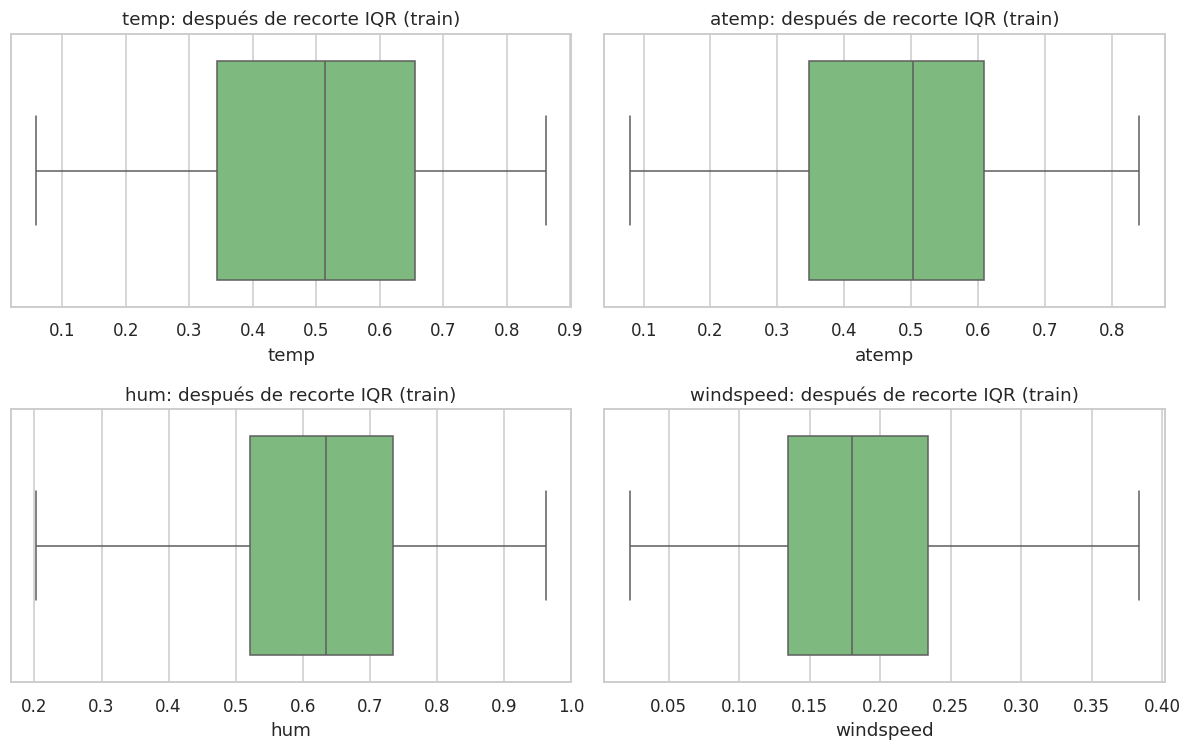

In [13]:
# Para PCA/K-Means se ajusta una vez en train; test solo se transforma.
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
print('X_train_prep:', X_train_prep.shape, '| X_test_prep:', X_test_prep.shape)
print('Número de features después de codificar:', len(feature_names))

clipper = preprocessor.named_transformers_['num'].named_steps['iqr_clip']
train_numeric_clipped = clipper.transform(X_train[numeric_features])
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for j, (col, ax) in enumerate(zip(numeric_features, axes.ravel())):
    sns.boxplot(x=train_numeric_clipped[:, j], ax=ax, color='#74c476')
    ax.set_title(f'{col}: después de recorte IQR (train)')
    ax.set_xlabel(col)
save_figure('08_boxplots_outliers_despues.png')

## 6. PCA: reducción de dimensionalidad

n_components seleccionado = 11; varianza acumulada = 0.8561


,componente,varianza explicada,varianza acumulada
0,1,0.3194,0.3194
1,2,0.1707,0.4901
2,3,0.1168,0.6068
3,4,0.0495,0.6563
4,5,0.0440,0.7004
5,6,0.0405,0.7409
6,7,0.0341,0.7749
7,8,0.0223,0.7972
8,9,0.0206,0.8179
9,10,0.0193,0.8372


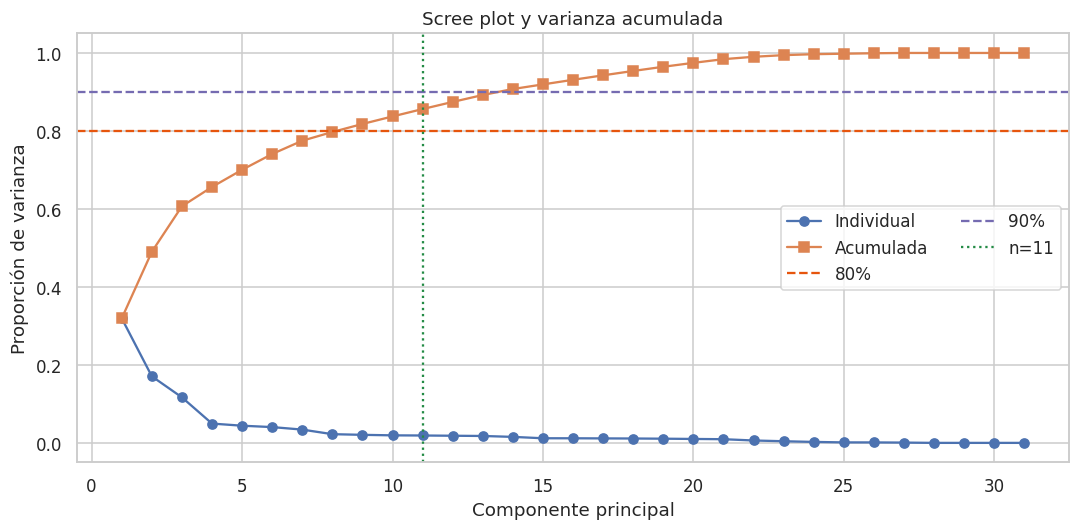

In [14]:
pca_full = PCA().fit(X_train_prep)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
pca_variance = pd.DataFrame({
    'componente': np.arange(1, len(explained)+1),
    'varianza explicada': explained,
    'varianza acumulada': cumulative
})
display(pca_variance.round(4))

eligible = np.where((cumulative >= 0.80) & (cumulative <= 0.90))[0]
n_components = int(eligible[np.argmin(np.abs(cumulative[eligible] - 0.85))] + 1)
print(f'n_components seleccionado = {n_components}; varianza acumulada = {cumulative[n_components-1]:.4f}')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(pca_variance['componente'], pca_variance['varianza explicada'], marker='o', label='Individual')
ax1.plot(pca_variance['componente'], pca_variance['varianza acumulada'], marker='s', label='Acumulada')
ax1.axhline(.80, color='#e6550d', linestyle='--', label='80%')
ax1.axhline(.90, color='#756bb1', linestyle='--', label='90%')
ax1.axvline(n_components, color='#238b45', linestyle=':', label=f'n={n_components}')
ax1.set_title('Scree plot y varianza acumulada')
ax1.set_xlabel('Componente principal')
ax1.set_ylabel('Proporción de varianza')
ax1.legend(ncol=2)
save_figure('09_pca_scree_plot.png')

Se escoge el número de componentes cuya varianza acumulada queda más próxima al 85% dentro del intervalo exigido de 80%-90%. Este punto conserva la mayor parte de la información sin retener toda la dimensionalidad generada por one-hot encoding.

,componente,loading
num__atemp,PC1,0.6398
num__temp,PC1,0.6373
num__windspeed,PC1,-0.2175
nom__season_3,PC1,0.1915
nom__season_1,PC1,-0.1868
num__hum,PC2,0.7576
num__windspeed,PC2,-0.5060
ord__weathersit,PC2,0.2760
num__temp,PC2,-0.1746
num__atemp,PC2,-0.1537


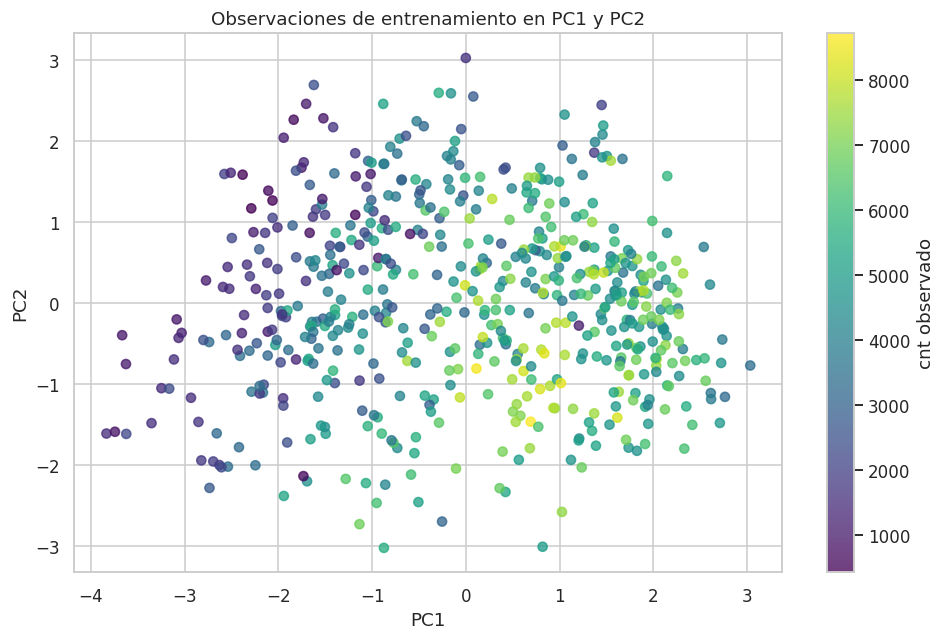

In [15]:
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_prep)
X_test_pca = pca.transform(X_test_prep)

plt.figure(figsize=(9, 6))
sc = plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='viridis', alpha=.76)
plt.colorbar(sc, label='cnt observado')
plt.title('Observaciones de entrenamiento en PC1 y PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
save_figure('10_pca_pc1_pc2_objetivo.png')

loadings = pd.DataFrame(pca.components_.T, index=feature_names,
                        columns=[f'PC{i}' for i in range(1, n_components+1)])
top_pc1 = loadings['PC1'].abs().nlargest(5).index
top_pc2 = loadings['PC2'].abs().nlargest(5).index
loading_report = pd.concat([
    loadings.loc[top_pc1, ['PC1']].rename(columns={'PC1':'loading'}).assign(componente='PC1'),
    loadings.loc[top_pc2, ['PC2']].rename(columns={'PC2':'loading'}).assign(componente='PC2')
])
display(loading_report[['componente','loading']].round(4))

## 7. K-Means sobre el espacio PCA

K óptimo por silhouette, contrastado con el codo: 2


,K,inercia,silhouette
0,2,2636.1043,0.2481
1,3,2277.9005,0.2078
2,4,2076.4009,0.1699
3,5,1918.3451,0.1662
4,6,1780.1483,0.1665
5,7,1675.6060,0.1657
6,8,1595.6633,0.1624
7,9,1533.6470,0.1607
8,10,1486.0503,0.1484


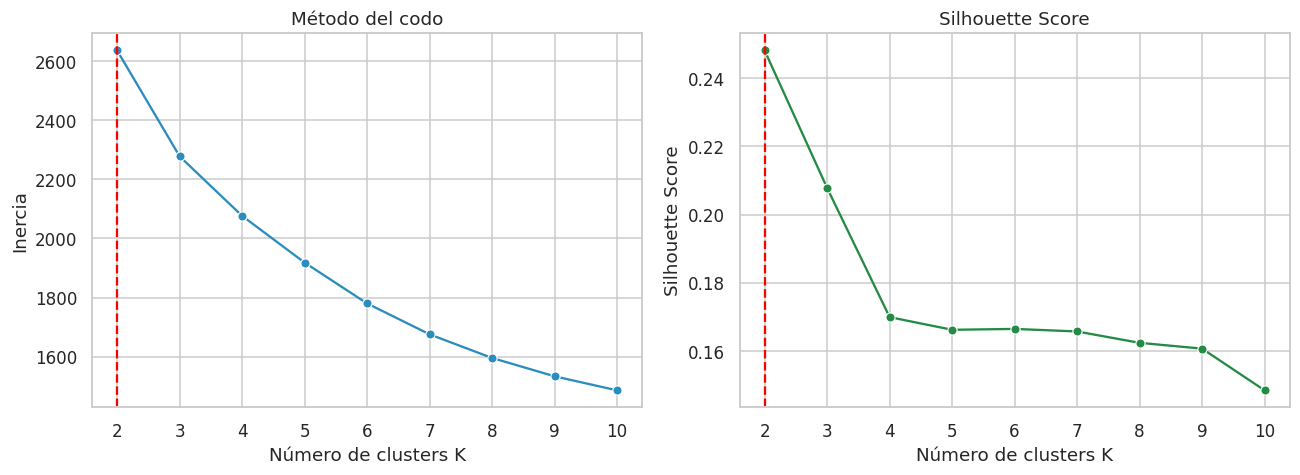

In [16]:
k_records = []
fitted_kmeans = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_train_pca)
    fitted_kmeans[k] = km
    k_records.append([k, km.inertia_, silhouette_score(X_train_pca, labels)])
k_eval = pd.DataFrame(k_records, columns=['K','inercia','silhouette'])
display(k_eval.round(4))
optimal_k = int(k_eval.loc[k_eval['silhouette'].idxmax(), 'K'])
print('K óptimo por silhouette, contrastado con el codo:', optimal_k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.lineplot(data=k_eval, x='K', y='inercia', marker='o', ax=axes[0], color='#2b8cbe')
axes[0].axvline(optimal_k, color='red', linestyle='--')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('Número de clusters K')
axes[0].set_ylabel('Inercia')
sns.lineplot(data=k_eval, x='K', y='silhouette', marker='o', ax=axes[1], color='#238b45')
axes[1].axvline(optimal_k, color='red', linestyle='--')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de clusters K')
axes[1].set_ylabel('Silhouette Score')
save_figure('11_kmeans_elbow_silhouette.png')

El K óptimo se selecciona por el máximo Silhouette Score y se verifica contra la caída de inercia. La solución K=2 ofrece la separación más clara; aumentar K reduce inercia, como siempre ocurre, pero disminuye la cohesión/separación relativa. Esta decisión privilegia segmentos estables y accionables sobre una fragmentación más difícil de explicar.

,n,cnt_media,cnt_mediana,temp,atemp,hum,windspeed,weathersit,workingday,yr
cluster,,,,,,,,,,
0,299,5606.214,5305.0,0.652,0.613,0.657,0.172,1.371,0.716,0.518
1,285,3464.396,3422.0,0.341,0.337,0.604,0.210,1.435,0.621,0.516


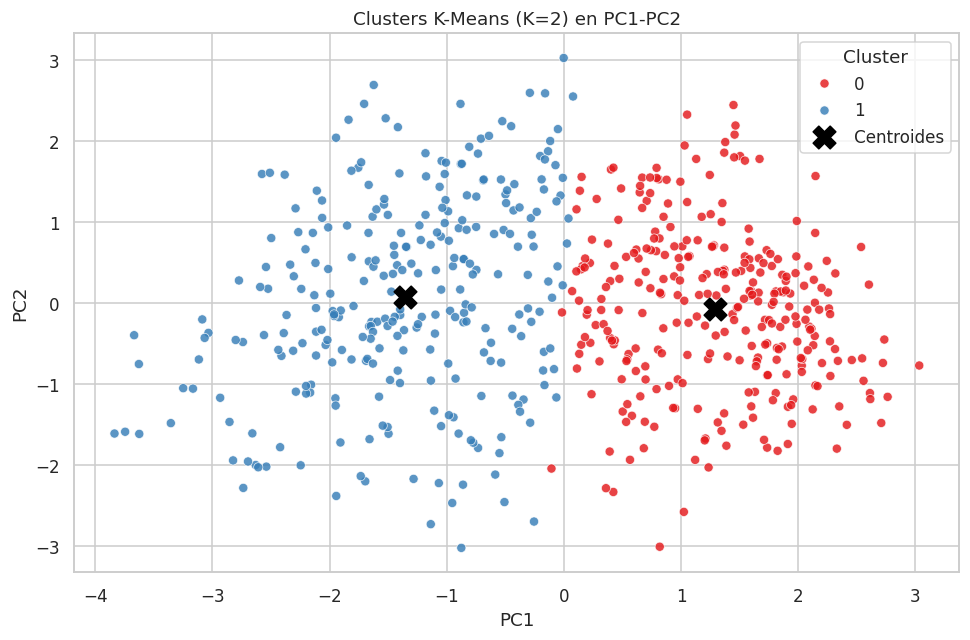

In [17]:
kmeans = fitted_kmeans[optimal_k]
train_clusters = kmeans.labels_
plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_train_pca[:,0], y=X_train_pca[:,1], hue=train_clusters,
                palette='Set1', alpha=.82)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            marker='X', s=220, c='black', label='Centroides')
plt.title(f'Clusters K-Means (K={optimal_k}) en PC1-PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
save_figure('12_kmeans_clusters_pca.png')

cluster_profile = X_train.assign(cnt=y_train, cluster=train_clusters).groupby('cluster').agg(
    n=('cnt','size'), cnt_media=('cnt','mean'), cnt_mediana=('cnt','median'),
    temp=('temp','mean'), atemp=('atemp','mean'), hum=('hum','mean'),
    windspeed=('windspeed','mean'), weathersit=('weathersit','mean'),
    workingday=('workingday','mean'), yr=('yr','mean')
)
display(cluster_profile.round(3))

### Interpretación ejecutiva de clusters

El cluster 0 reúne 299 días más cálidos (temperatura media normalizada cercana a 0,65) y alcanza aproximadamente 5.606 arriendos diarios. El cluster 1 reúne 285 días más fríos (temperatura cercana a 0,34), con algo más de viento, y promedia cerca de 3.464 arriendos. La proporción del segundo año es semejante en ambos grupos, por lo que la diferencia no se explica únicamente por crecimiento temporal. La conexión con el objetivo es explícita: K-Means no utilizó `cnt` para formar los grupos, pero los segmentos descubiertos separan regímenes de demanda alta y baja asociados principalmente al clima. Para negocio, el primer segmento requiere mayor disponibilidad y redistribución; el segundo permite planificar mantención y una dotación más conservadora, sin asumir que todos los días adversos serán iguales.

## 8. Modelos supervisados con validación cruzada

In [18]:
# El ColumnTransformer se incluye dentro de cada Pipeline. GridSearchCV lo reajusta
# en cada fold y evita que la validación vea estadísticas de otras particiones.
ridge_pipe = Pipeline([('prep', preprocessor), ('model', Ridge())])
rf_pipe = Pipeline([('prep', preprocessor),
                    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])

searches = {
    'Ridge': GridSearchCV(
        ridge_pipe,
        {'model__alpha':[0.001, 0.01, 0.1, 1, 10, 100]},
        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1,
        return_train_score=True
    ),
    'Random Forest': GridSearchCV(
        rf_pipe,
        {
            'model__n_estimators':[200, 400],
            'model__max_depth':[None, 8, 16],
            'model__min_samples_split':[2, 5, 10]
        },
        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1,
        return_train_score=True
    )
}
models, training_times = {}, {}
for name, search in searches.items():
    start = time.time()
    search.fit(X_train, y_train)
    training_times[name] = time.time() - start
    models[name] = search.best_estimator_
    print(f'{name}: mejores hiperparámetros = {search.best_params_}')
    print(f'{name}: mejor RMSE CV = {-search.best_score_:.4f}; tiempo = {training_times[name]:.4f} s')

Ridge: mejores hiperparámetros = {'model__alpha': 10}
Ridge: mejor RMSE CV = 805.0150; tiempo = 1.5889 s
Random Forest: mejores hiperparámetros = {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Random Forest: mejor RMSE CV = 726.7483; tiempo = 13.9263 s


In [19]:
def regression_metrics(y_true, pred):
    return {
        'RMSE': mean_squared_error(y_true, pred)**0.5,
        'MAE': mean_absolute_error(y_true, pred),
        'R2': r2_score(y_true, pred),
        'MAPE': mean_absolute_percentage_error(y_true, pred)
    }

records, predictions = [], {}
for name, model in models.items():
    infer_start = time.time()
    test_pred = model.predict(X_test)
    infer_time = time.time() - infer_start
    train_pred = model.predict(X_train)
    predictions[name] = {'train':train_pred, 'test':test_pred}
    train_m = regression_metrics(y_train, train_pred)
    test_m = regression_metrics(y_test, test_pred)
    records.append({
        'Modelo':name,
        **{f'{k}_train':v for k,v in train_m.items()},
        **{f'{k}_test':v for k,v in test_m.items()},
        'Tiempo_entrenamiento_s':training_times[name],
        'Tiempo_inferencia_test_s':infer_time
    })
comparison = pd.DataFrame(records).sort_values('RMSE_test').reset_index(drop=True)
display(comparison.round(4))
comparison.to_csv('model_comparison.csv', index=False)
print('Tabla exportada: model_comparison.csv')

Tabla exportada: model_comparison.csv


,Modelo,RMSE_train,MAE_train,R2_train,MAPE_train,RMSE_test,MAE_test,R2_test,MAPE_test,Tiempo_entrenamiento_s,Tiempo_inferencia_test_s
0,Random Forest,258.6190,178.9801,0.9818,0.0623,679.6695,441.6843,0.8848,1.4600,13.9263,0.0716
1,Ridge,765.3937,564.3093,0.8402,0.1821,827.9710,608.9786,0.8290,1.4984,1.5889,0.0048


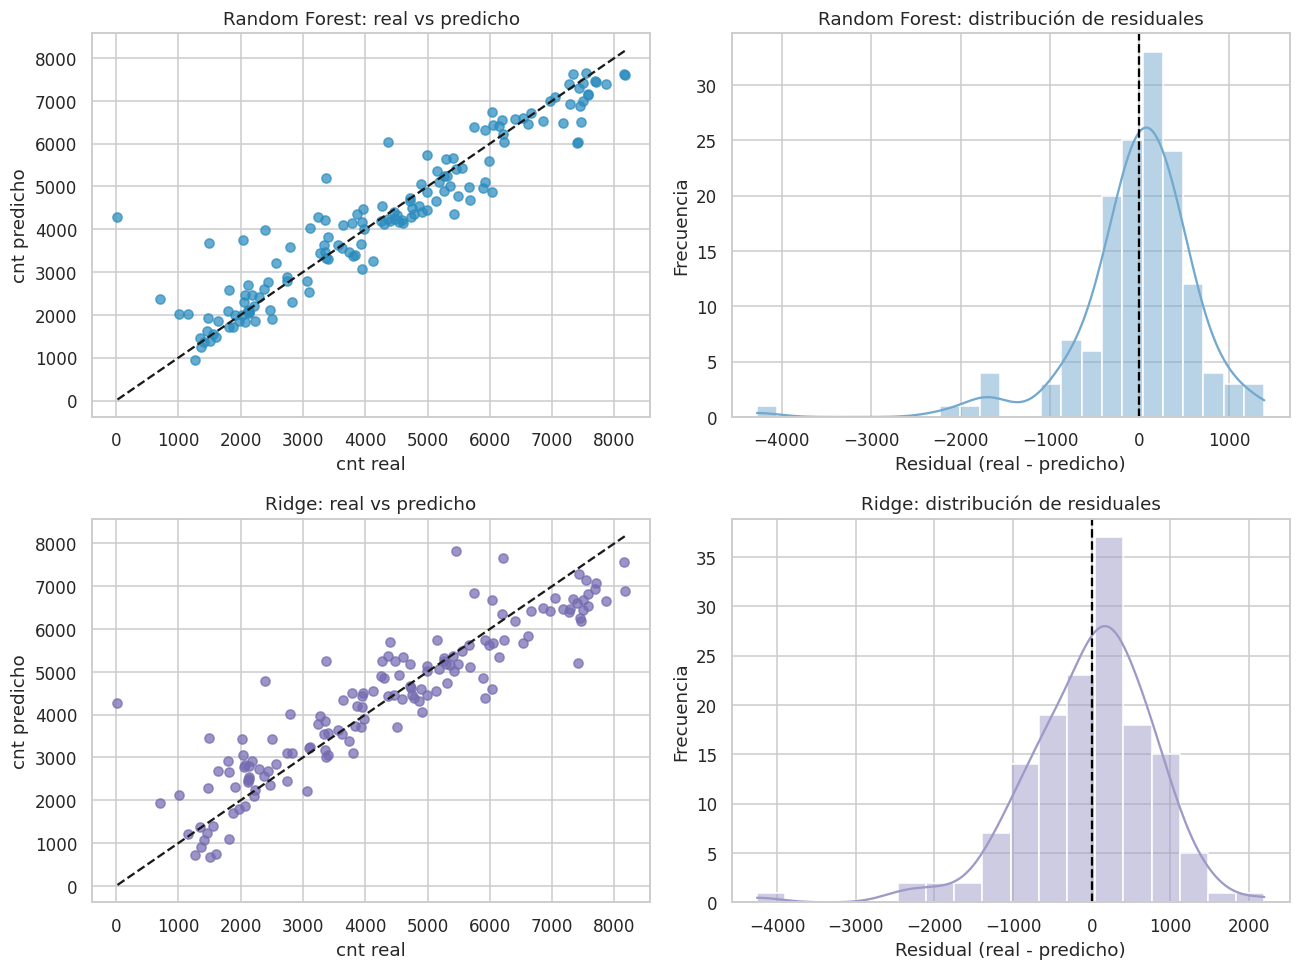

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for row, name in enumerate(comparison['Modelo']):
    pred = predictions[name]['test']
    axes[row,0].scatter(y_test, pred, alpha=.72, color=['#2b8cbe','#756bb1'][row])
    lo, hi = min(y_test.min(), pred.min()), max(y_test.max(), pred.max())
    axes[row,0].plot([lo,hi],[lo,hi],'k--')
    axes[row,0].set_title(f'{name}: real vs predicho')
    axes[row,0].set_xlabel('cnt real')
    axes[row,0].set_ylabel('cnt predicho')
    residuals = y_test.to_numpy() - pred
    sns.histplot(residuals, kde=True, ax=axes[row,1], color=['#74a9cf','#9e9ac8'][row])
    axes[row,1].axvline(0, color='black', linestyle='--')
    axes[row,1].set_title(f'{name}: distribución de residuales')
    axes[row,1].set_xlabel('Residual (real - predicho)')
    axes[row,1].set_ylabel('Frecuencia')
save_figure('13_modelos_predicciones_residuales.png')

### Selección del mejor modelo (más de 150 palabras)

Random Forest se selecciona como modelo final porque obtiene el menor RMSE de test, aproximadamente 679,67 arriendos, frente a 827,97 de Ridge, y el mayor R² de test, cercano a 0,8848. La mejora es material para planificación diaria. Sin embargo, la comparación train-test revela sobreajuste: su RMSE aumenta desde cerca de 258,62 en entrenamiento hasta 679,67 en test. La brecha se informa en lugar de ocultarse y obliga a tratar la predicción como apoyo, no como certeza. Ridge presenta una brecha menor y es más transparente: sus coeficientes permiten explicar dirección y magnitud relativa, pero no captura tan bien umbrales ni interacciones entre calendario y clima. En costo computacional, Ridge entrena e infiere más rápido; Random Forest demanda más tiempo por la búsqueda de profundidad, tamaño del bosque y división mínima. El MAPE resulta inestable porque algunos días tienen demanda real muy baja: un error absoluto moderado produce un porcentaje enorme. Por ello la decisión se apoya principalmente en RMSE, MAE y R². El balance final favorece Random Forest por desempeño, conservando Ridge como benchmark interpretable y usando análisis de importancia y errores para reducir la opacidad del bosque.

## 9. Importancia de variables y análisis de errores

,feature,importance
0,num__temp,0.353984
1,ord__yr,0.280355
2,num__atemp,0.150245
3,num__hum,0.059033
4,nom__season_4,0.036067
5,num__windspeed,0.031178
6,nom__season_1,0.021793
7,ord__weathersit,0.018675
8,ord__workingday,0.004614
9,nom__weekday_0,0.004561


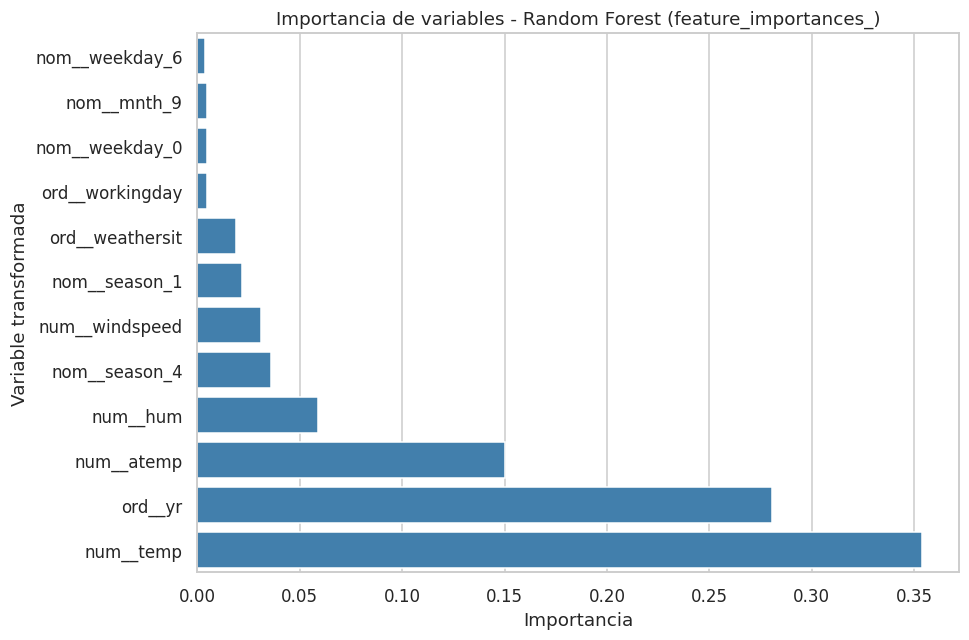

In [21]:
best_name = comparison.iloc[0]['Modelo']
best_model = models[best_name]
best_pred = predictions[best_name]['test']
best_prep = best_model.named_steps['prep']
transformed_names = best_prep.get_feature_names_out()
estimator = best_model.named_steps['model']
if hasattr(estimator, 'feature_importances_'):
    importance_values = estimator.feature_importances_
    importance_method = 'feature_importances_'
else:
    importance_values = np.abs(estimator.coef_)
    importance_method = '|coeficiente|'
importance = (pd.DataFrame({'feature':transformed_names, 'importance':importance_values})
              .sort_values('importance', ascending=False).reset_index(drop=True))
display(importance.head(10))

plt.figure(figsize=(9, 6))
plot_imp = importance.head(12).sort_values('importance')
sns.barplot(data=plot_imp, x='importance', y='feature', color='#3182bd')
plt.title(f'Importancia de variables - {best_name} ({importance_method})')
plt.xlabel('Importancia')
plt.ylabel('Variable transformada')
save_figure('14_feature_importance.png')

### Interpretación de las cinco variables principales

La importancia del modelo se concentra en señales temporales y meteorológicas. `yr` representa el crecimiento estructural del sistema entre 2011 y 2012; `temp` y `atemp` aproximan comodidad climática, por lo que aumentos moderados suelen ampliar la disposición a usar bicicleta; `weathersit` distingue días favorables de lluvia o nieve; y categorías estacionales o mensuales capturan patrones de movilidad no explicados solo por temperatura. Frente al EDA, existe coherencia: temperatura y año también aparecen entre las correlaciones más altas con `cnt`. La diferencia es que Random Forest reparte o alterna importancia entre predictores correlacionados, especialmente `temp` y `atemp`; por eso una importancia individual baja no implica ausencia de valor conjunto. En términos de negocio, la capacidad operativa debe anticipar simultáneamente tendencia de crecimiento, confort térmico y deterioro del clima, no basarse en una sola variable.

In [22]:
error_analysis = X_test.copy()
error_analysis['cnt_real'] = y_test
error_analysis['cnt_predicho'] = best_pred
error_analysis['residual'] = error_analysis['cnt_real'] - error_analysis['cnt_predicho']
error_analysis['error_absoluto'] = error_analysis['residual'].abs()
worst10 = error_analysis.nlargest(10, 'error_absoluto')
display(worst10.round(3))

error_pattern = pd.DataFrame({
    'grupo':['10 peores errores','resto de test'],
    'cnt_real_medio':[worst10.cnt_real.mean(), error_analysis.drop(worst10.index).cnt_real.mean()],
    'temp_media':[worst10.temp.mean(), error_analysis.drop(worst10.index).temp.mean()],
    'hum_media':[worst10.hum.mean(), error_analysis.drop(worst10.index).hum.mean()],
    'proporción_2012':[worst10.yr.mean(), error_analysis.drop(worst10.index).yr.mean()],
    'error_absoluto_medio':[worst10.error_absoluto.mean(), error_analysis.drop(worst10.index).error_absoluto.mean()]
})
display(error_pattern.round(3))
error_analysis.to_csv('test_predictions_and_errors.csv', index=True)

,temp,atemp,hum,windspeed,season,mnth,weekday,yr,holiday,workingday,weathersit,cnt_real,cnt_predicho,residual,error_absoluto
667,0.440,0.439,0.880,0.358,4,10,1,1,0,1,3,22,4297.730,-4275.730,4275.730
327,0.373,0.372,0.549,0.167,4,11,4,0,1,0,1,1495,3677.488,-2182.488,2182.488
448,0.502,0.487,0.885,0.193,2,3,6,1,0,0,2,3372,5206.925,-1834.925,1834.925
101,0.502,0.493,0.739,0.275,2,4,2,0,0,1,2,2034,3748.475,-1714.475,1714.475
473,0.463,0.457,0.569,0.168,2,4,3,1,0,1,2,4367,6042.960,-1675.960,1675.960
340,0.410,0.400,0.970,0.266,4,12,3,0,0,1,3,705,2374.525,-1669.525,1669.525
265,0.609,0.522,0.972,0.078,4,9,5,0,0,1,2,2395,3976.675,-1581.675,1581.675
550,0.789,0.732,0.539,0.135,3,7,3,1,1,0,1,7403,6008.475,1394.525,1394.525
568,0.668,0.623,0.762,0.094,3,7,0,1,0,0,2,7410,6034.632,1375.368,1375.368
456,0.426,0.417,0.676,0.172,2,4,0,1,0,0,2,6041,4865.992,1175.007,1175.007


,grupo,cnt_real_medio,temp_media,hum_media,proporción_2012,error_absoluto_medio
0,10 peores errores,3524.400,0.518,0.754,0.600,1887.968
1,resto de test,4334.482,0.473,0.605,0.423,336.116


**Patrones de fallo.** Los errores mayores tienden a corresponder a días de demanda excepcionalmente alta o baja respecto de lo esperable por calendario y clima. Esto sugiere variables omitidas: eventos masivos, interrupciones del servicio, promociones o shocks locales. El bosque reduce error medio, pero regresa hacia patrones frecuentes cuando enfrenta combinaciones escasas. La tabla permite auditar exactamente los diez casos y evita concluir a partir de un promedio agregado.

## 10. Conclusiones ejecutivas

El análisis demuestra que la demanda diaria de Capital Bikeshare puede modelarse con utilidad operacional a partir de calendario y clima, siempre que el flujo sea estrictamente libre de fuga. El EDA mostró un objetivo aproximadamente simétrico, por lo que no fue necesario aplicar logaritmo. También reveló una relación positiva entre temperatura y demanda, menor uso bajo clima adverso y un aumento estructural en 2012. La correlación casi perfecta entre `temp` y `atemp` confirmó multicolinealidad; se conservaron ambas variables porque Ridge regulariza coeficientes y Random Forest puede decidir entre señales redundantes. Los outliers meteorológicos se limitaron mediante IQR dentro del pipeline, sin eliminar días reales.

El análisis no supervisado resumió el espacio preprocesado mediante componentes que conservan alrededor del 85% de la varianza. K-Means favoreció dos segmentos: un régimen más cálido y de demanda alta, y otro más frío, con algo más de viento y demanda menor. `cnt` no participó en la formación de clusters; su diferencia posterior aporta una validación de negocio y conecta la segmentación con decisiones de capacidad.

Random Forest fue el modelo seleccionado por su menor RMSE de test y R² cercano a 0,8848. Ridge fue más rápido e interpretable, pero menos preciso. Las variables principales se vinculan con año, temperatura/sensación térmica, clima y estacionalidad. Esto coincide con el EDA, aunque la redundancia entre temperatura y sensación térmica distribuye la importancia.

El estudio tiene limitaciones específicas. Primero, solo cubre Washington D.C. y dos años, por lo que existe riesgo de cambio temporal y baja transportabilidad. Segundo, faltan eventos, disponibilidad de estaciones, precios, obras y transporte alternativo. Tercero, el split aleatorio no reproduce un despliegue estrictamente futuro y puede ser optimista ante estacionalidad. Cuarto, el objetivo diario oculta picos horarios y geográficos. Quinto, el MAPE es poco confiable en días de demanda muy baja.

Se recomiendan dos acciones inmediatas: usar el modelo para planificación con bandas de seguridad, priorizando RMSE/MAE, y monitorear mensualmente la brecha entre demanda real y pronosticada por clima y estación. Como trabajo futuro, se propone una validación temporal entrenando en 2011 y probando en 2012, incorporar eventos y disponibilidad por estación, y comparar Gradient Boosting con explicaciones SHAP. También conviene evaluar un modelo horario para redistribución intradía. Estas extensiones permitirían pasar de una demostración académica a una herramienta de decisión con vigilancia de drift, trazabilidad y actualización programada.

## 11. Referencias y declaración de uso de IA

- Fanaee-T, H. (2013). *Bike Sharing* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894
- Fanaee-T, H., & Gama, J. (2014). Event labeling combining ensemble detectors and background knowledge. *Progress in Artificial Intelligence, 2*, 113-127. https://doi.org/10.1007/s13748-013-0040-3
- Scikit-learn Developers. (2026). *User Guide: preprocessing, model selection, PCA, clustering and ensemble methods*. https://scikit-learn.org/stable/user_guide.html
- Material docente de la asignatura Machine Learning I, clases 1-10 (2026), proporcionado por el profesor en el aula virtual.

**Declaración de IA generativa.** Se utilizó ChatGPT (OpenAI) como apoyo para estructurar el notebook, revisar código, mejorar redacción y verificar cobertura de la rúbrica. Oscar Aguilera revisó la lógica, ejecutó el análisis y es responsable de comprender, validar y presentar las decisiones y resultados. No se incorporó material ajeno sin referencia.

In [23]:
# Resumen auditable para README y guion.
summary = {
    'dataset_shape': list(df.shape),
    'target_skewness': float(target_skew),
    'pca_n_components': int(n_components),
    'pca_cumulative_variance': float(cumulative[n_components-1]),
    'optimal_k': int(optimal_k),
    'best_model': best_name,
    'best_metrics_test': {k:float(v) for k,v in regression_metrics(y_test, best_pred).items()},
    'best_params': searches[best_name].best_params_,
    'top5_features': importance.head(5)['feature'].tolist(),
    'top5_correlations': top5_corr.index.tolist()
}
Path('results').mkdir(exist_ok=True)
Path('results/summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
display(summary)

{'dataset_shape': [731, 16], 'target_skewness': -0.04735278011900183, 'pca_n_components': 11, 'pca_cumulative_variance': 0.8561314512624806, 'optimal_k': 2, 'best_model': 'Random Forest', 'best_metrics_test': {'RMSE': 679.6694809568344, 'MAE': 441.6842517006803, 'R2': 0.8847969665694795, 'MAPE': 1.4599940463333871}, 'best_params': {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 400}, 'top5_features': ['num__temp', 'ord__yr', 'num__atemp', 'num__hum', 'nom__season_4'], 'top5_correlations': ['atemp', 'temp', 'yr', 'season', 'weathersit']}